## How to create pyAPES forcing file?

Samuli Launiainen 2.7.2024

Modified by Santeri Satalahti 23 Apr 2026 

Ability to gapfill the input variables
- short gaps: interpolation
- Long gaps: with era5 data
    - precipitation data in era5 is not good
    - Longwave radiation is gapfilled with mean diurnal cycle


### We create here pyAPES forcing for FI-Ran 


*Forcing variables; ascii-file, sep=';'*

- year: YYYY
- month: MM 
- day: dd 
- hour: hh 
- minute: mm 
- doy: decimal day of year
- Prec (kg m-2 30min-1): accumulated precipitation during timestep
- P (Pa): atm. pressure
- Tair (degC): air temperature
- U (m s-1): mean wind speed
- Ustar (m s-1): friction velocity (possible to run also with fixed U/Ustar -value) 
- H2O (Pa): vapor pressure
- CO2 (ppm): CO2 mixing ratio - here we assume 390.0 for 2011-2014 period as data was noisuy
- Zen (rad): solar zenith angle; one can use *pyAPES.microclimate.radiation.solar_angles* to compute. Double-check timestamps (timezone) so that Zen matches observed radiation cycles

*Radiation inputs:*
- LWin (W m-2) - incoming longwave radiation. Measured or can be estimated from atmospheric emissivity and near-surface air temperature
- diffPar, dirPar (W m-2): direct and diffuse Par 
- diffNir, dirNir (W m-2): direct and diffuse Nir 

We assume now 0.42 of measured global radiation is Par and 0.58 Nir, supported by site data (see below) and Proutsos et al. 2022. Atmospheric Research, 269.
As diffuse fraction was not measured, we estimate it from theoretical clear-sky radiation and observed global radiation (*pyAPES.microclimate.radiation.compute_clouds_rad*)

*For Planttype phenology* (optional, for intializing vascular plant LAI and relative photosynthetic capacity)
- DDsum (degC): temperature sum
- X (degC): stage of development (Kolari et al. 2009)

*Soil state (optional, for imposing soil boundary conditions)*
- SWC (m3m-3)
- Ts (degC)

In [3]:
# set pyAPES project to path
import sys
import os
from dotenv import load_dotenv
import pathlib

load_dotenv()
# pyAPES_main_folder = os.getenv('pyAPES_main_folder')
# sys.path.append(pyAPES_main_folder)


pyAPES_main_folder = pathlib.Path(os.getenv("pyAPES_main_folder")).resolve()
sys.path.insert(0, str(pyAPES_main_folder))

FI_ran_folder = pathlib.Path(os.getenv("FI_ran_folder")).resolve()

# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget

In [4]:
os.path.isdir(pyAPES_main_folder) 

True

### Define site location and time offset from UTC
- needed for 1) gapfilling data and 2) calculating solar angeles

In [5]:
lat = 61.18292236 # latitude in degrees
lon = 25.26955414 # longitude in degrees
timeoffset = 0 # offset from UTC (h)

### Read L2, L3 and BIOMET data 

- Data follows LUKE's data format. 
    - L2 and Biomet datasets are quality controlled but contain gaps. L3 data is gapfilled and is used for model evaluation.


- prepare model forcing
<!-- - prepare model evaluation dataset -->


In [6]:

# L2 data is quality controlled flux data, L3 is gapfilled flux data and biomet is biomet data

ecdata_L2_22  = f'{FI_ran_folder}\\L2\\EC_flux_L2_final_FI-Ran_2022.csv'
ecdata_L2_23  = f'{FI_ran_folder}\\L2\\EC_flux_L2_final_FI-Ran_2023.csv'
ecdata_L2_24  = f'{FI_ran_folder}\\L2\\EC_flux_L2_final_FI-Ran_2024.csv'
ecdata_L2_25  = f'{FI_ran_folder}\\L2\\EC_flux_L2_final_FI-Ran_2025.csv'
ecdata_L3_22  = f'{FI_ran_folder}\\L3\\EC_flux_L3_final_FI-Ran_2022.csv'
ecdata_L3_23  = f'{FI_ran_folder}\\L3\\EC_flux_L3_final_FI-Ran_2023.csv'
ecdata_L3_24  = f'{FI_ran_folder}\\L3\\EC_flux_L3_final_FI-Ran_2024.csv'
ecdata_L3_25  = f'{FI_ran_folder}\\L3\\EC_flux_L3_final_FI-Ran_2025.csv'
biometdata_22 = f'{FI_ran_folder}\\biomet\\biomet_final_30min_FI-Ran_2022.csv'
biometdata_23 = f'{FI_ran_folder}\\biomet\\biomet_final_30min_FI-Ran_2023.csv'
biometdata_24 = f'{FI_ran_folder}\\biomet\\biomet_final_30min_FI-Ran_2024.csv'
biometdata_25 = f'{FI_ran_folder}\\biomet\\biomet_final_30min_FI-Ran_2025.csv'

# read to dataframes, skip the unit row (clear cut)
ec_l2_22_df = pd.read_csv(ecdata_L2_22,  header=0, skiprows=[1]) # L2
ec_l2_23_df = pd.read_csv(ecdata_L2_23,  header=0, skiprows=[1])
ec_l2_24_df = pd.read_csv(ecdata_L2_24,  header=0, skiprows=[1])
ec_l2_25_df = pd.read_csv(ecdata_L2_25,  header=0, skiprows=[1])
ec_l3_22_df = pd.read_csv(ecdata_L3_22,  header=0, skiprows=[1]) # L3
ec_l3_23_df = pd.read_csv(ecdata_L3_23,  header=0, skiprows=[1])
ec_l3_24_df = pd.read_csv(ecdata_L3_24,  header=0, skiprows=[1])
ec_l3_25_df = pd.read_csv(ecdata_L3_25,  header=0, skiprows=[1])
bio_22_df   = pd.read_csv(biometdata_22, header=0, skiprows=[1]) # bio
bio_23_df   = pd.read_csv(biometdata_23, header=0, skiprows=[1])
bio_24_df   = pd.read_csv(biometdata_24, header=0, skiprows=[1])
bio_25_df   = pd.read_csv(biometdata_25, header=0, skiprows=[1])


input_dfs = [ec_l2_22_df, ec_l2_23_df, ec_l2_24_df, ec_l2_25_df, ec_l3_22_df, ec_l3_23_df, ec_l3_24_df, ec_l3_25_df, bio_22_df, bio_23_df, bio_24_df, bio_25_df]
for df in input_dfs:
    # convert timestamp to datetime and set as index
    timestamp_col = df.columns[0]
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df.dropna(subset=[timestamp_col], inplace=True)
    df.set_index(timestamp_col, inplace=True)
    df.index.names = ['datetime']
    df.replace(-9999.0, np.nan, inplace=True) # set to nan

df22 = ec_l2_22_df.join(bio_22_df).join(ec_l3_22_df)
df23 = ec_l2_23_df.join(bio_23_df).join(ec_l3_23_df)
df24 = ec_l2_24_df.join(bio_24_df).join(ec_l3_24_df)
df25 = ec_l2_25_df.join(bio_25_df).join(ec_l3_25_df)
for df in [df22, df23, df24, df25]:
    df["SHF_mean"] = df[["SHF_1_1_1", "SHF_2_1_1", "SHF_3_1_1"]].mean(axis=1, skipna=True) # mean surface heat flux from 3 sensors
    df["SWC_mean"] = df[["SWC_1_1_1", "SWC_2_1_1", "SWC_3_1_1"]].mean(axis=1, skipna=True) # mean soil water content from 3 sensors
    df["TS_mean"] = df[["TS_1_1_1", "TS_2_1_1", "TS_3_1_1"]].mean(axis=1, skipna=True) # mean soil temperature from 3 sensors
    df.drop(columns=["SHF_1_1_1", "SHF_2_1_1", "SHF_3_1_1"], inplace=True)
    df.drop(columns=["SWC_1_1_1", "SWC_2_1_1", "SWC_3_1_1"], inplace=True)
    df.drop(columns=["TS_1_1_1", "TS_2_1_1", "TS_3_1_1"], inplace=True)
    df = df[~df.index.duplicated(keep='first')]
    df.dropna(inplace=True)

raw = pd.concat([df22, df23, df24, df25], axis=0)

# ensure the index is sorted and has no duplicates nor gaps
raw.sort_index(inplace=True)
full_index = pd.date_range(
    start=raw.index.min(),
    end=raw.index.max(),
    freq="30min"   # 30‑minute frequency
)
raw = raw.reindex(full_index)

# raw.columns.to_list()


C:\Users\03246754\AppData\Local\Temp\ipykernel_2536\3420106117.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["SHF_mean"] = df[["SHF_1_1_1", "SHF_2_1_1", "SHF_3_1_1"]].mean(axis=1, skipna=True) # mean surface heat flux from 3 sensors
C:\Users\03246754\AppData\Local\Temp\ipykernel_2536\3420106117.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["SWC_mean"] = df[["SWC_1_1_1", "SWC_2_1_1", "SWC_3_1_1"]].mean(axis=1, skipna=True) # mean soil water content from 3 sensors
C:\Users\03246754\AppData\Local\Temp\ipykernel_

### Create output dataframe

#### Define pathlib path objects for forcing data location

In [7]:
forcing_outfile = pathlib.Path(rf'{pyAPES_main_folder}/forcing/FI-Ran/FI-Ran_forcing_2022_2025.dat')
# fluxes_outfile = pathlib.Path(rf'{pyAPES_main_folder}/forcing/FI-Ran/FI-Ran_L3_2022_2025.dat')

#### Create dataframe

In [8]:
fcols = ['year', 'month', 'day', 'hour', 'minute', 'doy',
         'Prec','P','Tair', 'U', 'Ustar', 'H2O', 'CO2', 
         'Zen', 'LWin', 'diffPar', 'dirPar', 'diffNir', 'dirNir',
         'DDsum', 'X', 'Tdaily', 'Tsoil', 'SWC']

forcing = pd.DataFrame(data=None, columns=fcols, index=raw.index)

forcing['year'] = raw.index.year
forcing['month'] = raw.index.month
forcing['day'] = raw.index.day
forcing['hour'] = raw.index.hour
forcing['minute'] = raw.index.minute
forcing['doy'] = raw.index.dayofyear

## Set variables to forcing
These variables can be found directly from the input data. Gaps will be filled later.

In [9]:
forcing['CO2'] = 390.0 # ppm, assumed constant

forcing['Prec'] = raw['P_RAIN_1_1_1']
forcing['P'] = raw['PA_1_1_1'] *1000 
forcing['Tair'] = raw['TA_1_1_1']
forcing['U'] = raw['wind_speed']
forcing['Ustar'] = raw['UST_final']
forcing['Tsoil'] = raw['TS_mean']
forcing['SWC'] = raw['SWC_mean']
print(forcing.columns.to_list())


['year', 'month', 'day', 'hour', 'minute', 'doy', 'Prec', 'P', 'Tair', 'U', 'Ustar', 'H2O', 'CO2', 'Zen', 'LWin', 'diffPar', 'dirPar', 'diffNir', 'dirNir', 'DDsum', 'X', 'Tdaily', 'Tsoil', 'SWC']


### Gapfill predictor data with ERA5
variables in forcing:
[ 'Prec', 'P', 'Tair', 'U', 'Ustar', 'H2O', 'CO2', 'Zen', 'LWin', 'Tsoil', 'SWC']

variables in raw: 'SWIN_1_1_1', 'RH_1_1_1'

- First gapfill short gaps with linear interpolation

- download era5 data from openmeteo and scale each var linearly to match the surface. Exceptions for some variables.
- If caching doesn't work, it downloads the same data over and over again. Repeated API calls may rise errors from the openmeteo server

LWin is gapfilled with mean diurnal cycle

In [10]:

import openmeteo_requests
import requests_cache
from retry_requests import retry
import sklearn

def download_reanalysis_data_from_openmeteo(lat,lon,ts,te, cache_request =None):
    ''' Download weather data from Open-Meteo Weather API for the given latitude and longitude (float) and time period between ts and te (datetime). 
    Function adapted from the example at https://pypi.org/project/openmeteo-requests/ (Apr 28 2026)'''

    te = te + pd.Timedelta(hours=24)

    variables_in_ERA5_Land = ["temperature_2m", "relative_humidity_2m", "soil_temperature_7_to_28cm", "soil_moisture_7_to_28cm"]
    variables_in_ERA5 = ["precipitation","pressure_msl", "wind_speed_10m", "wind_direction_10m","shortwave_radiation","boundary_layer_height"]
    accumulated_variables = ["precipitation", "shortwave_radiation"]

    if cache_request == True:  # potential ssl error, investigate
        # Setup the Open-Meteo API client with cache and retry on error
        cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
        retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
        openmeteo = openmeteo_requests.Client(session = retry_session)
    else:
        openmeteo = openmeteo_requests.Client() # does not use cache and retry but works most of the time 

    # Make sure all required weather variables are listed here
    # The order of variables in hourly or daily is important to assign them correctly below
    url = "https://archive-api.open-meteo.com/v1/archive"
    params_era5_land = {
        "latitude": [lat],
        "longitude": [lon],
        "start_date": ts.strftime("%Y-%m-%d"),
        "end_date": te.strftime("%Y-%m-%d"),
        "hourly": variables_in_ERA5_Land,
        "wind_speed_unit": "ms",
        "models": "era5_land"
    }
    params_era5 = {
        "latitude": [lat],
        "longitude": [lon],
        "start_date": ts.strftime("%Y-%m-%d"),
        "end_date": te.strftime("%Y-%m-%d"),
        "hourly": variables_in_ERA5,
        "wind_speed_unit": "ms",
        "models": "era5"
    }

    # download ERA5-Land data
    responses = openmeteo.weather_api(url, params=params_era5_land)
    response = responses[0]

    hourly = response.Hourly()
    hourly_variables = list(map(lambda i: hourly.Variables(i), range(0, hourly.VariablesLength())))

    timevec = (np.arange(hourly.Time(), hourly.TimeEnd(), hourly.Interval())).astype('datetime64[s]').tolist()

    df_era5_land = pd.DataFrame(index=timevec,columns=variables_in_ERA5_Land)

    for idx in range(len(hourly_variables)):
        df_era5_land[variables_in_ERA5_Land[idx]] = hourly_variables[idx].ValuesAsNumpy()

    # download ERA5 data
    responses = openmeteo.weather_api(url, params=params_era5)
    response = responses[0]

    hourly = response.Hourly()
    hourly_variables = list(map(lambda i: hourly.Variables(i), range(0, hourly.VariablesLength())))

    timevec = (np.arange(hourly.Time(), hourly.TimeEnd(), hourly.Interval())).astype('datetime64[s]').tolist()

    df_era5 = pd.DataFrame(index=timevec,columns=variables_in_ERA5)

    for idx in range(len(hourly_variables)):
        df_era5[variables_in_ERA5[idx]] = hourly_variables[idx].ValuesAsNumpy()

    # concat era5 and era5-land datafrarmes
    dfout = pd.concat([df_era5_land,df_era5],axis=1)

    dfout = dfout.astype(float)

    # for accumulated variables, changing the time stamp to correspond to the beginning of the accumulation period
    for acc_var in accumulated_variables:
        dfout[acc_var] = dfout[acc_var].shift(-1)

    return dfout

def GapfillWithERA5(df, vrgf, lat, lon):
    ''' Gapfill vrgf in df with ERA5 data from Open-Meteo. If there are gaps, it downloads the time series and resamples to match 30min frequency. 
    For each month (or longer period), a linear regression is fitted between the available measurements and the corresponding ERA5 data,
    and this regression is used to scale the era5 data to fit the measurements. For some variables (e.g. temperature and humidity), a median offset between measurements
    and ERA5 is calculated for each time of day and used to adjust the regression estimates. 
    
    An R2 score is calculated for each filled period, take it cum grano salis with vars like wind or precipitation 

    Note: The index of the input dataframe must not contain any gaps and must be datetime. Gapfilling fails if the input df and the era5 df indexes are not identical.


    INPUTS: - df: dataframe with variable to gapfill, indexed by datetime. 
            - vrgf: variable to gapfill (string)
            - lat, lon: coordinates for downloading ERA5 data

    OUTPUT: - dataframe with variable vrgf gapfilled with ERA5 data, indexed by datetime
    '''
    bmdf30 = df.copy()
    
    if bmdf30[vrgf].isna().sum()==0:
        return bmdf30
    
    ts = bmdf30.index[0]
    te = bmdf30.index[-1]

    try:
        # initially try to cache the request to avoid repeated downloads 
        radf = download_reanalysis_data_from_openmeteo(lat, lon, ts, te, cache_request=True)
    except Exception:
        try:
            radf = download_reanalysis_data_from_openmeteo(lat, lon, ts, te, cache_request=False)
        except Exception as e:
            print(f'Failed to download ERA5 data from Open-Meteo. {vrgf} not gapfilled. Error: {e}')
            return bmdf30
    
    radf30 = radf.resample('30min').interpolate(method='linear')
    radf30 = radf30.loc[(radf30.index >= bmdf30.index.min()) & (radf30.index <= bmdf30.index.max())]
    # print(radf30)

    if 'pressure_msl' in radf30.columns:
        radf30['pressure_msl'] = radf30['pressure_msl'] *100 # to kPa

    # variables that can be gapfilled, make sure they're mapped to corresponding era5 vars
    varmap = {'Tair':'temperature_2m',
    'P':'pressure_msl',
    'Prec':'precipitation',
    'U':'wind_speed_10m',
    'Tsoil':'soil_temperature_7_to_28cm',
    'SWC':'soil_moisture_7_to_28cm',
    'RH_1_1_1':'relative_humidity_2m',
    'SWIN_1_1_1':'shortwave_radiation'}

    bmdf_gf = pd.DataFrame(index=bmdf30.index,columns=[vrgf])
    #bmdf_gf[vrgf] = bmdf30[vrgf].copy()

    try:
        bmdf_gf[vrgf] = bmdf30[vrgf].copy()
    except Exception as e:
        print(e)

    initial_n_gaps = bmdf_gf[vrgf].isna().sum()

    r2_scores = []
    var = vrgf
    
    for yr in bmdf_gf.index.year.unique():
        for mo in np.arange(1,13):
            try:
                # idx = (bmdfout.index.year==yr) & (bmdfout.index.month==mo)
                idxnn = (bmdf30.index.year==yr) & (bmdf30.index.month==mo) & (~bmdf30[var].isna()) # not nan
                idxn = (bmdf30.index.year==yr) & (bmdf30.index.month==mo) & (bmdf_gf[var].isna()) # nan

                if idxn.sum()==0:
                    continue

                if idxnn.sum()<30:
                    idxnn = (bmdf30.index.year==yr) & ((bmdf30.index.month==mo) | (bmdf30.index.month==mo-1) | (bmdf30.index.month==mo+1)) & (~bmdf30[var].isna())
                
                if idxn.loc[idxn==True].index.day[0] < 3: # if gaps at start of the month, use also previous month.
                    # print(var, mo, idxn.sum())
                    idxnn = (bmdf30.index.year==yr) & ((bmdf30.index.month==mo) | (bmdf30.index.month==mo-1)) & (~bmdf30[var].isna())

                if idxnn.sum()<30:
                    # if not enough data, use whole year and just use the era5 data for gapfilling
                    idxnn = (bmdf30.index.year==yr) & (~bmdf30[var].isna())          

                if (var == 'SWIN_1_1_1') or (var == 'U') or (var == 'SWC'):
                    # U should probably have log scaling instead of this
                    p = np.polyfit(radf30.loc[idxnn,varmap[var]],bmdf30.loc[idxnn,var],1)
                    x =  np.polyval(p,radf30.loc[idxn,varmap[var]])
                    r2 = sklearn.metrics.r2_score(bmdf30.loc[idxnn,var], np.polyval(p,radf30.loc[idxnn,varmap[var]]))

                elif var == 'P':
                    # determine the shift between era5 and measurements and adjust
                    # would be better to calculate the shift with hydrostatic pressure
                    pdiff = (radf30.loc[idxnn, varmap[var]]- bmdf30.loc[idxnn,var]).median()
                    x = radf30.loc[idxn,varmap[var]] - pdiff
                    r2 = sklearn.metrics.r2_score(bmdf30.loc[idxnn,var], radf30.loc[idxnn,varmap[var]] - pdiff)

                elif (var == 'Tair') or (var == 'RH_1_1_1') or (var == 'Tsoil'):
                    # median offset between era5 and measurements for each time of day
                    tod_nn = bmdf30.loc[idxnn].index.time
                    tdiff = (radf30.loc[idxnn, varmap[var]] - bmdf30.loc[idxnn, var]).groupby(tod_nn).median()

                    # match offsets to missing timestamps
                    tod_n = bmdf30.loc[idxn].index.time
                    tod_nn = bmdf30.loc[idxnn].index.time
                    offset_vec = pd.Series(tod_n).map(tdiff).to_numpy()
                    offset_test = pd.Series(tod_nn).map(tdiff).to_numpy()

                    p = np.polyfit(radf30.loc[idxnn,varmap[var]] - offset_test,bmdf30.loc[idxnn,var],1)
                    x =  np.polyval(p,radf30.loc[idxn,varmap[var]] - offset_vec)

                    # adjust regression estimate by offset
                    # x = x - offset_vec
                    x_test = np.polyval(p,radf30.loc[idxnn,varmap[var]] - offset_test)

                    if var == 'RH_1_1_1':
                        x = np.clip(x, a_min=None, a_max=100)
                        x_test = np.clip(x_test, a_min=None, a_max=100)

                    r2 = sklearn.metrics.r2_score(bmdf30.loc[idxnn,var], x_test)
                else:
                    # for other variables, just use the era5 data without adjustment
                    x = radf30.loc[idxn,varmap[var]]
                    r2 = sklearn.metrics.r2_score(bmdf30.loc[idxnn,var], radf30.loc[idxnn,varmap[var]])

                r2_scores.append(r2)
                bmdf_gf.loc[idxn,var] = x # copy gapfilled data to bmdfout

            except Exception as e:
                pass 
                # print(e)

    # copy gapfilled variable to output dataframe
    bmdf30[vrgf] = bmdf_gf[vrgf].copy()
    r2 = np.mean(r2_scores) # mean r2 score for the gapfilling of vrgf over all time periods
    if bmdf30[vrgf].isna().sum()==0:
        msg = f'Successfully filled {initial_n_gaps} gaps from {vrgf} with ERA5 data. R2 score for gapfilling: {r2:.2f}.'
        # logger.info(msg)
        print(msg)
    else:
        msg = f'Failed to gapfill {vrgf} with ERA5 data.'
        # logger.warning(msg)
        print(msg)

    return bmdf30

def interpolate_short_gaps(df, var, ngaps):
        dfgf = df.copy()
        initial_n_gaps = dfgf[var].isna().sum() 
        dfgf[var] = dfgf[var].interpolate(method="linear", limit=ngaps, limit_direction="both")
        final_n_gaps = dfgf[var].isna().sum()
        print(f'Interpolated {initial_n_gaps - final_n_gaps} gaps in {var}.')

        return dfgf


def gapfill_MDC(df, var):
    dfgf = df.copy()
    initial_n_gaps = dfgf[var].isna().sum()

    max_gap_days = 10
    window_days = 14
    sigma_days = 7  # controls how strongly recent days are weighted

    if not isinstance(dfgf.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex")

    # --- helper: find contiguous gaps ---
    def get_gaps(series):
        is_nan = series.isna().values
        gaps = []
        start = None

        for i, val in enumerate(is_nan):
            if val and start is None:
                start = i
            elif not val and start is not None:
                gaps.append((start, i - 1))
                start = None

        if start is not None:
            gaps.append((start, len(series) - 1))

        return gaps

    # --- helper: weighted MDC ---
    def compute_weighted_mdc(window_df, center_time):
        dfw = window_df.copy()

        # distance in days from gap center
        delta_days = (dfw.index - center_time).total_seconds() / 86400.0
        weights = np.exp(-(delta_days ** 2) / (2 * sigma_days ** 2))

        dfw = dfw.assign(weight=weights)

        # group by time-of-day (48 slots for 30-min data)
        grouped = dfw.groupby(dfw.index.time)

        def wmean(x):
            v = x[var]
            w = x["weight"]
            mask = v.notna()
            if mask.sum() == 0:
                return np.nan
            return np.sum(v[mask] * w[mask]) / np.sum(w[mask])

        return grouped.apply(wmean)

    # --- iterative filling ---
    while True:
        gaps = get_gaps(dfgf[var])

        valid_gaps = []
        for s, e in gaps:
            gap_len_days = (e - s + 1) * 0.5 / 24  # 30-min steps → days
            if gap_len_days <= max_gap_days:
                valid_gaps.append((s, e, gap_len_days))

        if not valid_gaps:
            break

        # shortest gaps first
        valid_gaps.sort(key=lambda x: x[2])

        filled_any = False

        for s, e, _ in valid_gaps:
            gap_index = dfgf.index[s:e+1]
            gap_center = gap_index[len(gap_index) // 2]

            start_time = gap_index[0] - pd.Timedelta(days=window_days)
            end_time = gap_index[-1] + pd.Timedelta(days=window_days)

            window_df = dfgf.loc[start_time:end_time]

            # require some data
            if window_df[var].notna().sum() < 20:
                continue

            mdc = compute_weighted_mdc(window_df, gap_center)

            for ts in gap_index:
                if pd.isna(dfgf.at[ts, var]):
                    tod = ts.time()
                    val = mdc.get(tod, np.nan)
                    if not np.isnan(val):
                        dfgf.at[ts, var] = val
                        filled_any = True

        if not filled_any:
            break

    final_n_gaps = dfgf[var].isna().sum()
    print(f'Filled {initial_n_gaps - final_n_gaps} gaps in {var} with MDC.')

    return dfgf

In [11]:
# set unrealistic U values to nan (quick fix)
forcing.loc[forcing['U'] > 61.6, 'U'] = np.nan


In [ ]:
for var in ['Prec', 'P', 'Tair', 'U', 'Tsoil', 'SWC']:
    forcing = interpolate_short_gaps(forcing, var, ngaps=5)
    forcing[var] = GapfillWithERA5(forcing, var, lat, lon)[var]




Interpolated 306 gaps in Prec.
Successfully filled 1307 gaps from Prec with ERA5 data. R2 score for gapfilling: -1.90.
Interpolated 349 gaps in P.
Successfully filled 3524 gaps from P with ERA5 data. R2 score for gapfilling: 1.00.
Interpolated 354 gaps in Tair.
Successfully filled 7064 gaps from Tair with ERA5 data. R2 score for gapfilling: 0.86.
Interpolated 337 gaps in U.
Successfully filled 1730 gaps from U with ERA5 data. R2 score for gapfilling: 0.47.
Interpolated 343 gaps in Tsoil.
Successfully filled 17768 gaps from Tsoil with ERA5 data. R2 score for gapfilling: 0.72.
Interpolated 343 gaps in SWC.
Successfully filled 17768 gaps from SWC with ERA5 data. R2 score for gapfilling: 0.41.


In [14]:
for var in [ 'RH_1_1_1', 'SWIN_1_1_1']:
    raw = interpolate_short_gaps(raw, var, ngaps=5)
    raw[var] = GapfillWithERA5(raw, var, lat, lon)[var]


raw = interpolate_short_gaps(raw, 'LWIN_1_1_1', ngaps=5)
raw['LWIN_1_1_1'] = gapfill_MDC(raw, 'LWIN_1_1_1')['LWIN_1_1_1']


Interpolated 339 gaps in RH_1_1_1.
Successfully filled 5213 gaps from RH_1_1_1 with ERA5 data. R2 score for gapfilling: 0.74.
Interpolated 367 gaps in SWIN_1_1_1.
Successfully filled 2021 gaps from SWIN_1_1_1 with ERA5 data. R2 score for gapfilling: 0.82.
Interpolated 319 gaps in LWIN_1_1_1.
Filled 2021 gaps in LWIN_1_1_1 with MDC.


In [15]:
def plot_gap_length_distribution(df, var):

    if var not in df.columns:
        raise ValueError(f"Column '{var}' not found in DataFrame")

    # Boolean mask of missing values
    is_na = df[var].isna()

    # Identify consecutive gaps using group IDs
    gap_groups = (is_na != is_na.shift()).cumsum()

    # Compute lengths of NaN runs only
    gap_lengths = (
        is_na
        .groupby(gap_groups)
        .sum()
    )

    # Keep only actual gaps (length > 0)
    gap_lengths = gap_lengths[gap_lengths > 0]

    if gap_lengths.empty:
        print("No gaps found (no NaN sequences).")
        return

    # Plot
    plt.figure()
    plt.hist(gap_lengths, bins=range(1, gap_lengths.max() + 2))
    plt.xlabel("Gap length (consecutive NaNs)")
    plt.ylabel("Frequency")
    plt.title(f"Gap length distribution for '{var}'")
    plt.show()

# plot_gap_length_distribution(raw, 'LWIN_1_1_1')

## Radiation variables

- use *pyAPES.microclimate.radiation.solar_angles* for zenith angle (Zen)
- use *pyAPES.microclimate.radiation.compute_clouds_rad* to estimate cloud cover, diffuse fraction and atm. emissivity
- LW<sub>in</sub> could be then computed as: $LW_\mathrm{in} = \varepsilon_\mathrm{atm} \sigma (T_\mathrm{air} + T_{K})^4$ where $\varepsilon_\mathrm{atm}$ is the atmospheric emissivity and $T_K$ is 273.15
- Radiation variables need T<sub>air</sub> and [H<sub>2</sub>O]<sub>air</sub> so we calculate them here to forcing

In [16]:
from pyAPES.microclimate.radiation import solar_angles, compute_clouds_rad
from pyAPES.microclimate.micromet import e_sat

from pyAPES.utils.constants import DEG_TO_RAD, DEG_TO_KELVIN, PAR_TO_UMOL

fpar = 0.42 # ratio of Par/Global

### Compute julian day

In [19]:
jday = forcing.index.dayofyear + forcing.index.hour / 24 + forcing.index.minute / (24*60)
jday = jday.values

### Compute global radiation, air temperature and vpd

In [17]:
# global radiation, air temperature, rh and air pressure
rg = raw['SWIN_1_1_1'].values # Wm-2 # gapfilled
ta = forcing['Tair'].values # degC # gapfilled
es, _ = e_sat(ta) # saturation vapor pressure [Pa]

# rh is gappy, FluxNet2015 variable 'VPD_F' [hPa] is gap-filled
rh = raw['RH_1_1_1'].values # gapfilled
#rh = np.maximum(1.0, np.minimum(rh, 100.0)) # make rh be in realistic range
h2o = rh / 100 *es # vapor pressure [Pa]

# vpd = 100 * raw['VPD_F'].values #[Pa]
# h2o = es - vpd
# rh = h2o / es
#rh = np.maximum(1.0, np.minimum(rh, 100.0)) # make rh be in realistic range
#h2o = rh / 100 *es # vapor pressure [Pa]


### Compute solar zenith angle

In [20]:
# compute solar zenit angle and estimate diffuse fraction
zen, azim, decl, sunrise, sunset, daylength = solar_angles(lat, lon, jday, timezone=timeoffset)
elev_angle = 90 - zen / DEG_TO_RAD



# Compute cloud and diffuse fraction and $\varepsilon_\mathrm{atm}$

In [35]:
fcloud, fdiff, emi_sky = compute_clouds_rad(jday, zen, rg, h2o, ta)
fcloud = np.clip(fcloud, a_min=0.0, a_max=1.0) # quick fix for some unrealistic values, investigate


### Plot incoming SW, solar elevation and compute_clouds_rad output

Text(0, 0.5, 'cloud fraction (-)')

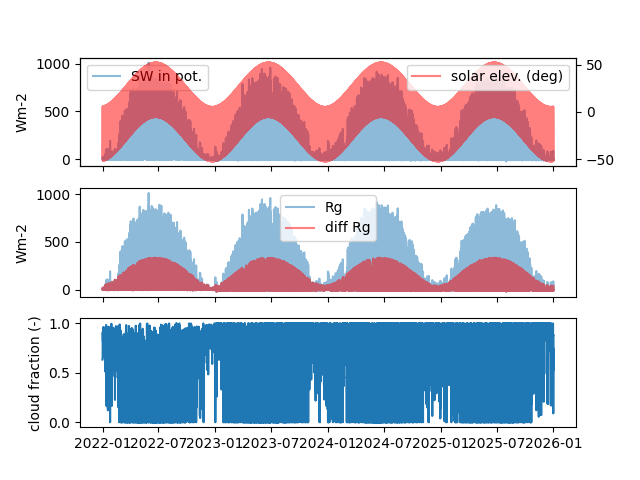

In [36]:
t = raw.index

fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, raw['SWIN_1_1_1'].values, '-', alpha=0.5, label='SW in pot.'), 
ax[0].legend(loc='upper left')
ax[0].set_ylabel('Wm-2')
axb = ax[0].twinx()
axb.plot(t, elev_angle, 'r-', alpha=0.5, label='solar elev. (deg)')
axb.legend(loc='upper right')

ax[1].plot(t, rg, '-', alpha=0.5, label='Rg')
ax[1].plot(t, fdiff * rg, 'r-', alpha=0.5, label='diff Rg')
ax[1].legend()
ax[1].set_ylabel('Wm-2')

ax[2].plot(t, fcloud, '-')
ax[2].set_ylabel('cloud fraction (-)')

In [37]:
# fcould2 = fcloud.copy()
# fcould2 = np.clip(fcould2, a_min=0.0, a_max=1.0)
# plt.figure()
np.where(fcloud >1.0)[0].shape[0]/fcloud.shape[0]

# plt.plot(t, fcould2, '-')

0.0

### Update forcing

In [38]:
# forcing['Tair'] = ta
forcing['H2O'] = 1000 * h2o / forcing['P'].values # mmol/mol = ppth
forcing['Zen'] = zen
forcing['LWin'] = raw['LWIN_1_1_1'].values
forcing['dirPar'] = fpar * (1 - fdiff) * rg
forcing['diffPar'] = fpar *  fdiff * rg
forcing['dirNir'] = (1 - fpar) * (1 - fdiff) * rg
forcing['diffNir'] = (1 - fpar) *  fdiff * rg

## Friction velocity
fill gaps by median of U/Ustar -ratio ~8.78

Median U/U*: 4.287818604149807


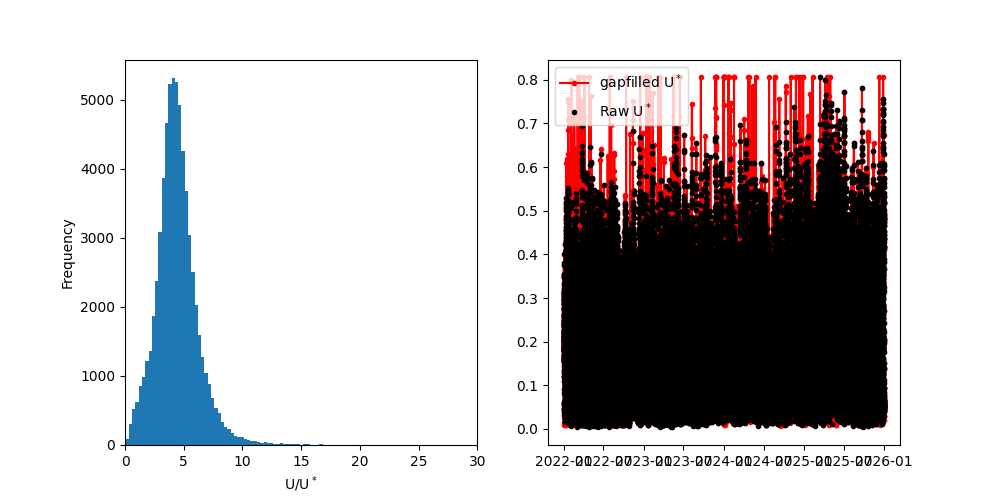

In [44]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

# not optimal

# y = raw['wind_speed'] / (raw['UST_final'] + 0.01)
y = forcing['U'] / (raw['UST_final'] + 0.01)
ix = np.where(y > 0)[0]
ax[0].hist(y.iloc[ix], 100)
ax[0].set_xlim([0,30])
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('U/U$^*$')
median_u_ust = np.median(y.iloc[ix])
print(f'Median U/U*: {median_u_ust}')

ust_f = raw['UST_final'].copy()
ixm = np.where(np.isnan(ust_f))[0]
# ust_f.iloc[ixm] = raw['wind_speed'].iloc[ixm] / median_u_ust
ust_f.iloc[ixm] = forcing['U'].iloc[ixm] / median_u_ust

ust_f = np.clip(ust_f, a_min=0.01, a_max=raw['UST_final'].max()) # quick fix for some unrealistic values, investigate
ax[1].plot(ust_f, 'r.-', label='gapfilled U$^*$')
ax[1].plot(raw['UST_final'], 'k.', label='Raw U$^*$')
ax[1].legend()

### Update forcing

In [45]:

forcing['Ustar'] = ust_f.values
forcing['Ustar'].isna().sum()

np.int64(0)

## Degree-day sum and phenology modifier
- from *pyAPES.planttype.phenology*

In [ ]:
# x = raw['SW_IN_F'].values # incoming shortwave radiation W m-2
# y = raw['PPFD_IN'].values / PAR_TO_UMOL #PAR W m-2
# ix = np.where((x > 0) & (y >0))[0]

# p = np.polyfit(x[ix], y[ix], 1)
# fit = np.polyval(p, [0.0, max(x[ix])])

# fig, ax = plt.subplots(1,1, figsize=(6,6))
# fig.subplots_adjust(bottom=0.2, left=0.3)
# ax.plot(x[ix], y[ix], 'ro')
# ax.plot([0.0, max(x[ix])], fit, 'k-', label='%.2f' %p[0])
# ax.legend()
# ax.set_xlabel('SW in')
# ax.set_ylabel('PAR')


In [46]:
def degree_days(Tdaily, jday, Tbase=+5.0):
    N = len(Tdaily)
    y = np.zeros(N)
    
    for k in range(1, N):
        if jday[k] == 1:
            y[k] = 0.0
        else:
            y[k] = y[k-1] + np.max([Tdaily[k] - Tbase, 0.0])
    return y

def pheno_state(T, tau, x0 = 0.0):
    X = np.zeros(len(T)) + np.nan
    X[0] = x0
    for k in range(1, len(X)):
        X[k] = X[k-1] + 1.0 / tau * (T[k] - X[k-1])  # degC
    return X

In [47]:
# Functions work on daily mean temperature
Tday = forcing['Tair'].resample('1D').mean() # already gapfilled Tair

doy = Tday.index.day_of_year

DDsum = degree_days(Tday.values, doy)
X = pheno_state(Tday.values, tau=8.0, x0=Tday.iloc[0])

tmp = pd.DataFrame(Tday)
tmp['DDsum'] = DDsum
tmp['X'] = X

# re-index and interpolate by forward-filling, except 1st day
tmp = tmp.reindex(index=raw.index)
tmp = tmp.ffill()
tmp = tmp.bfill()

# update forcing
forcing['Tdaily'] = tmp['Tair'].values
forcing['DDsum'] = tmp['DDsum'].values
forcing['X'] = tmp['X'].values

## Plot forging variables & save to file
- Check that there are no gaps in the forcing

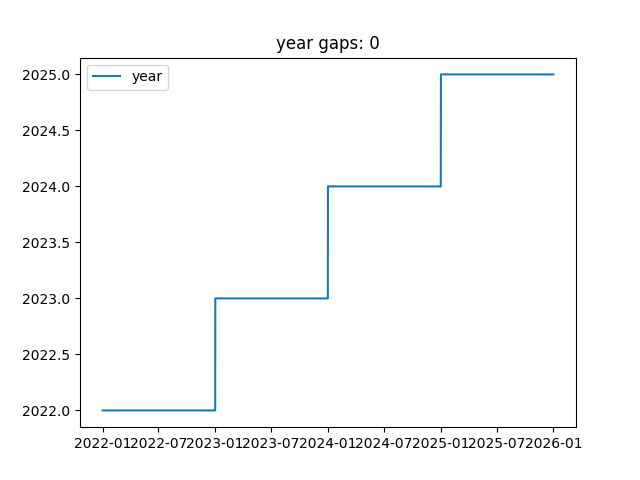

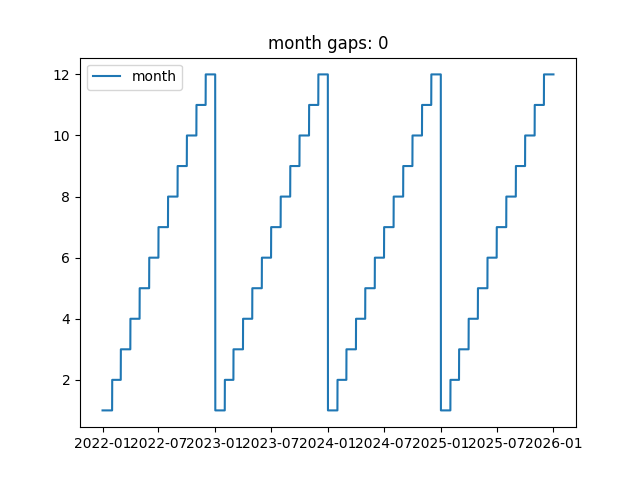

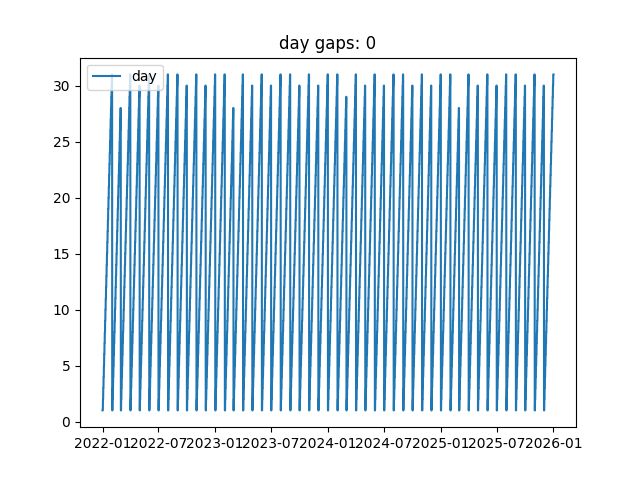

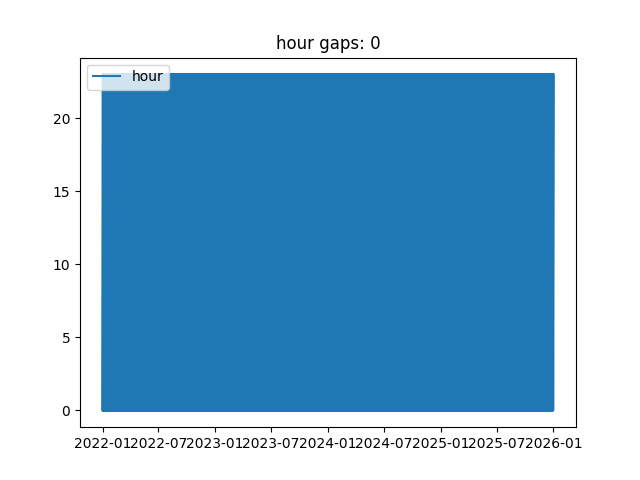

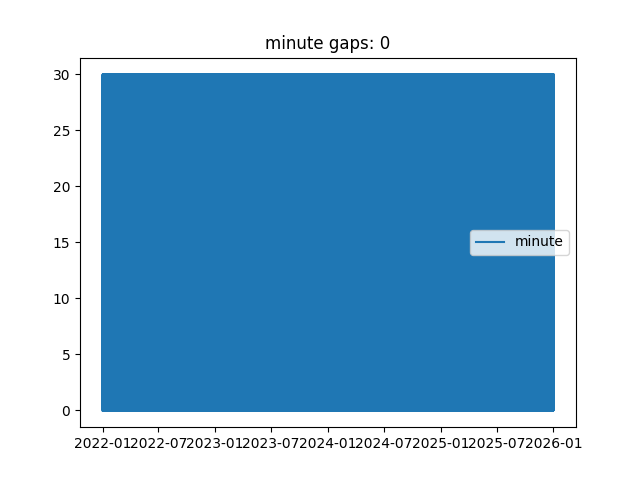

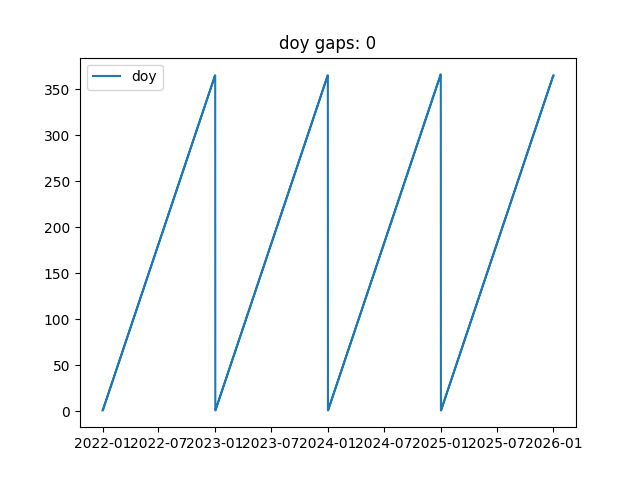

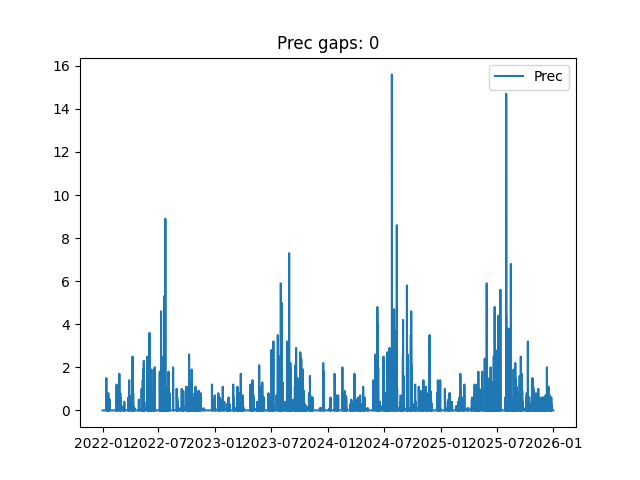

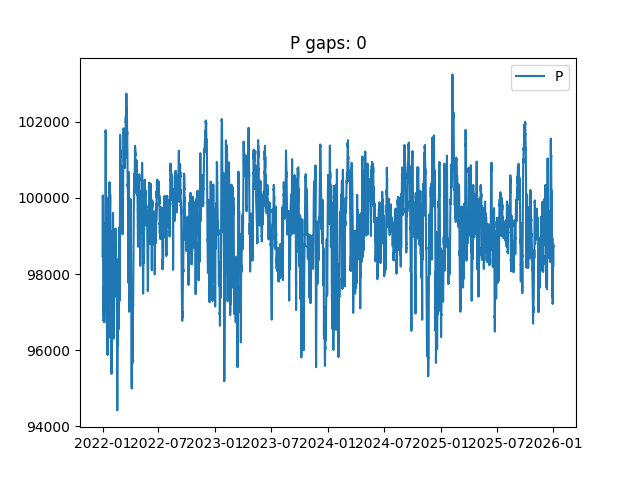

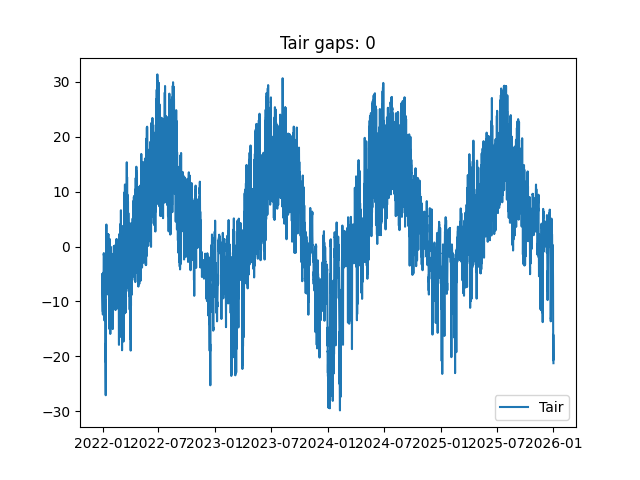

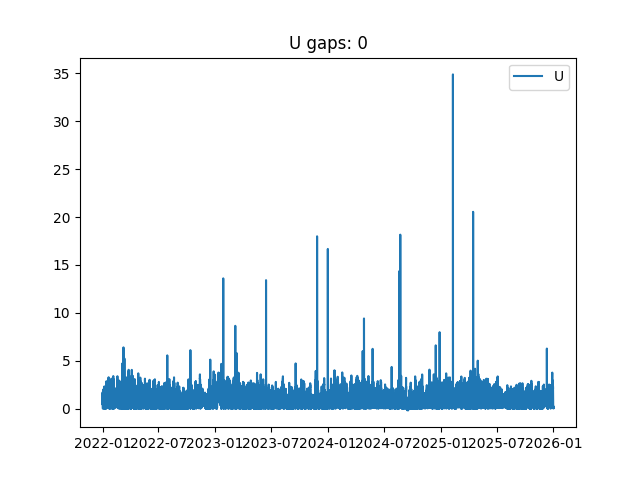

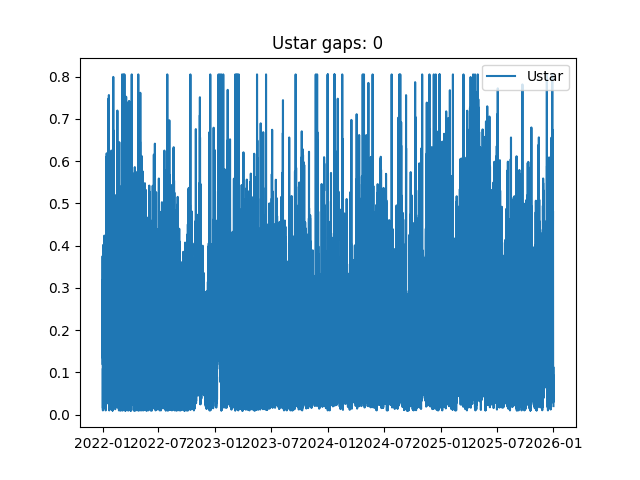

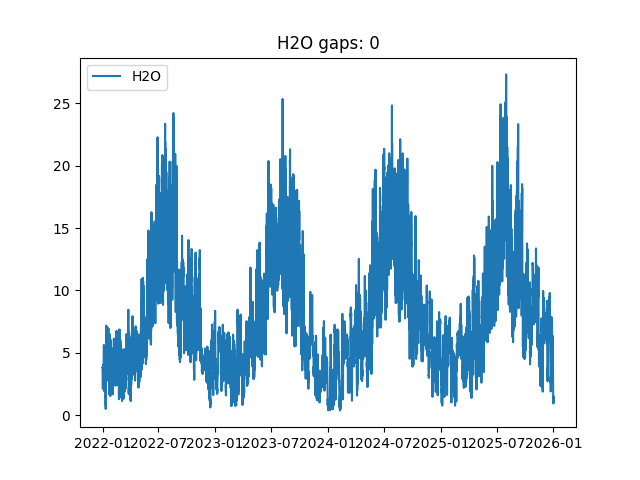

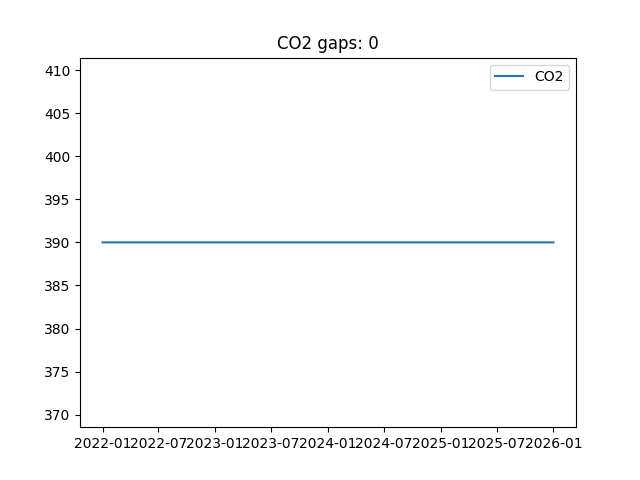

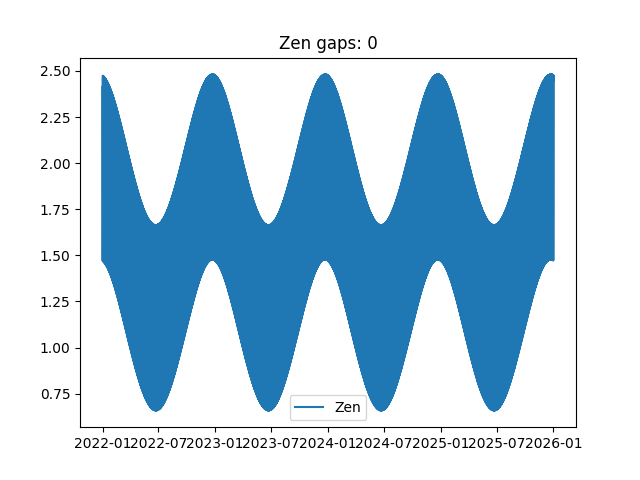

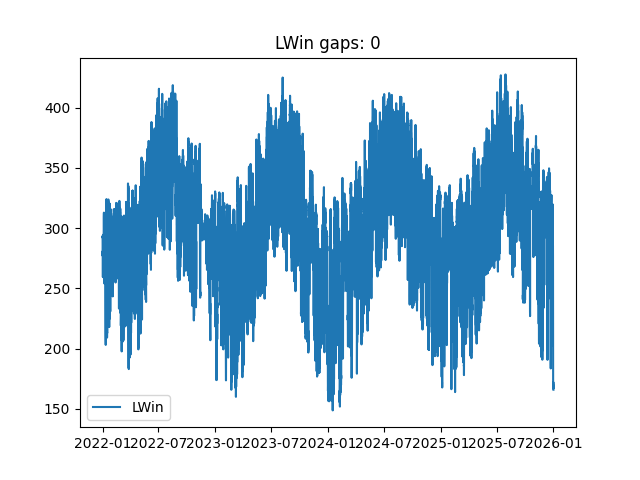

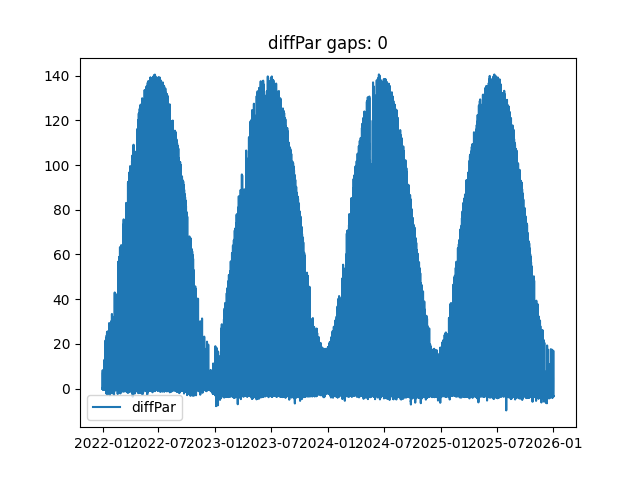

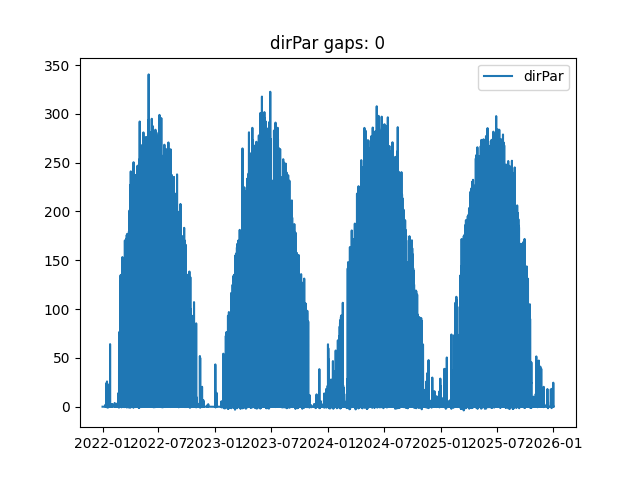

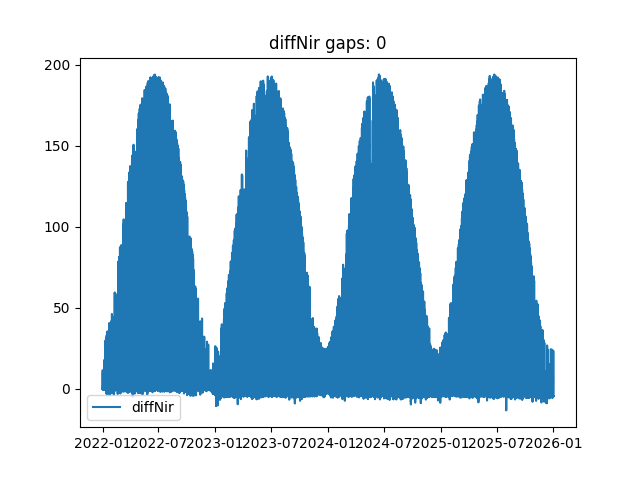

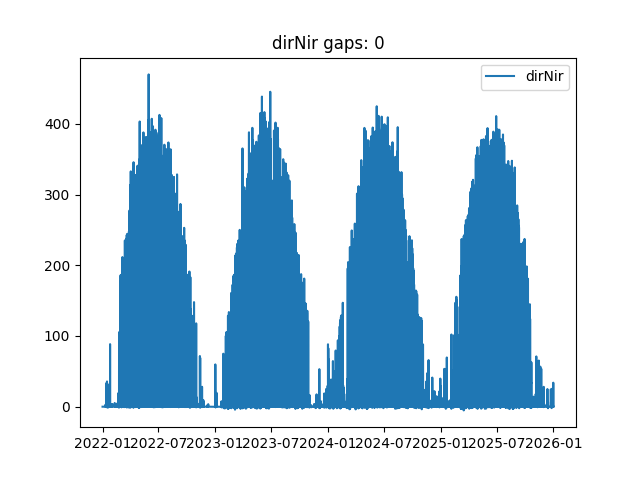

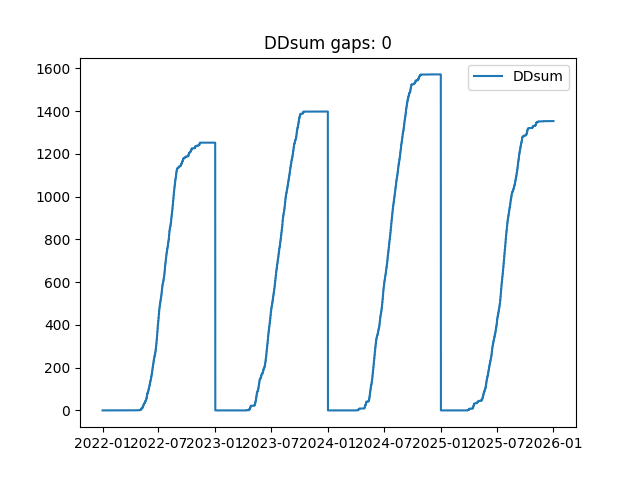

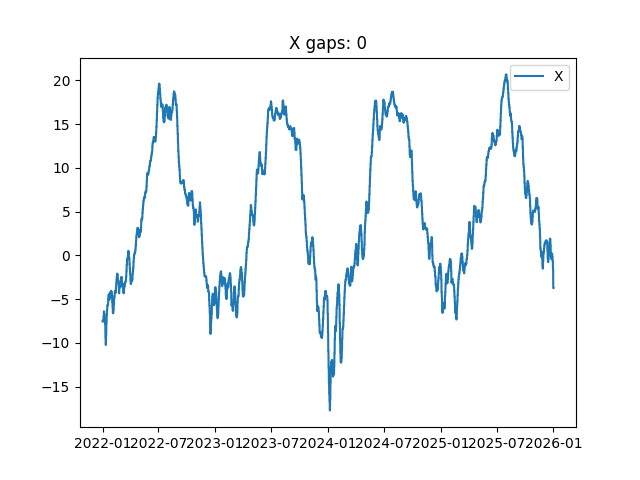

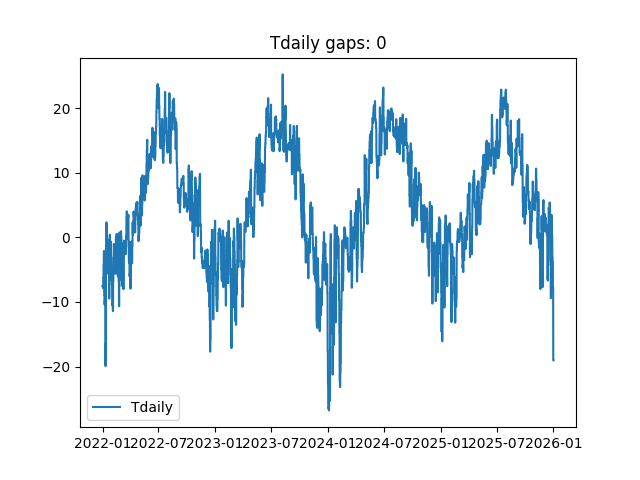

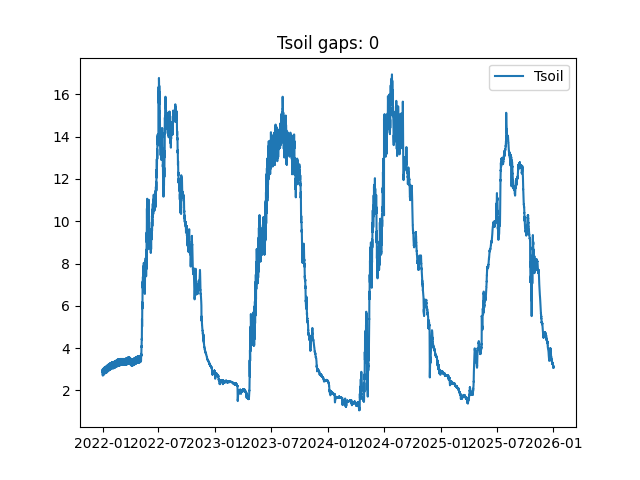

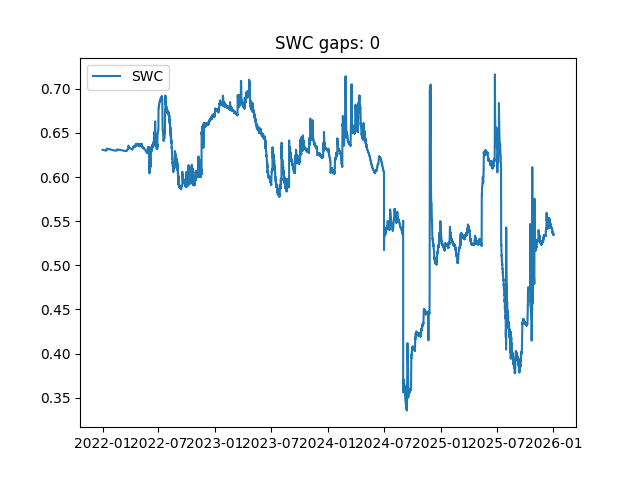

In [48]:
# forcing = forcing[(forcing.index >= '2011-01-01')] # ignore 2010 as no soil temperature or moisture

for col in forcing.columns:
    plt.figure()
    plt.plot(forcing[col], label=col)
    gaps = len(np.where(np.isnan(forcing[col]))[0])
    plt.title(col + ' gaps: %d' %gaps)
    #plt.xlim(['2011-01-01', '2013-01-01'])
    plt.legend()

In [ ]:
# forcing.isna().sum()

In [ ]:
# uncomment to save output forcing file
# forcing[['year', 'month', 'day', 'hour', 'minute', 'doy']].astype(int)
# forcing.to_csv(forcing_outfile, sep=';', float_format='%.3f', index=False)
# plt.close('all')

### Extract Fluxnet2015 data subset for model evaluation

Additional data to benchmark model runs:

- Nakai et al. 2013 Polar Sci. http://dx.doi.org/10.1016/j.polar.2013.03.003: ET, energy balance, Tsoil and SWC in 2021
- Ikawa et al. 2018 Agric. For. Met. http://dx.doi.org/10.1016/j.agrformet.2015.08.247: sub-canopy fluxes and flux partitioning

In [ ]:
fcols = [# radiation variables
         'NETRAD', 'SW_IN_F', 'PPFD_IN', 'PPFD_OUT', 'SW_OUT', 'LW_IN_F', 'LW_OUT',
         # energy fluxes
         'H_F_MDS', 'H_RANDUNC', 'H_CORR', 'H_CORR_25', 'H_CORR_75', 
         'LE_F_MDS', 'LE_RANDUNC', 'LE_CORR', 'LE_CORR_25', 'LE_CORR_75',
         'G_F_MDS',
         # NEE, GPP, RECO
         'NEE_VUT_REF', 'NEE_VUT_REF_RANDUNC',
         'GPP_NT_VUT_REF', 'GPP_DT_VUT_REF',
         'RECO_NT_VUT_REF', 'RECO_DT_VUT_REF',
         'TA_F', 'TS_F_MDS_1', 'P_F', 'SWC_F_MDS_2', 'WS_F', 'WD', 'NIGHT',
         # quality flags
         'SW_IN_F_QC', 'LW_IN_F_QC', 'H_F_MDS_QC', 'LE_F_MDS_QC', 'G_F_MDS_QC', 'NEE_VUT_REF_QC', 'VPD_F_QC', 'TA_F_QC', 'P_F_QC'
         ]

flx = raw[fcols]
flx = flx[(flx.index >='2011-01-01')]

elev_angle = 90.0 - forcing['Zen'] / DEG_TO_RAD
ix = np.where(elev_angle <10.0)[0]
sw_alb = flx['SW_OUT'] / (flx['SW_IN_F'] + 0.01)
sw_alb.iloc[ix] = np.nan
sw_alb[(sw_alb > 1.0) | (sw_alb < 0)] = np.nan

par_alb = flx['PPFD_OUT'] / (flx['PPFD_IN'] + 0.01)
par_alb.iloc[ix] = np.nan
par_alb[(par_alb > 1.0) | (par_alb < 0)] = np.nan

flx.insert(7,'SW_ALB', sw_alb.values)
flx.insert(8,'PPDF_ALB', par_alb.values)
flx.insert(0,'year', flx.index.year)
flx.insert(1,'month', flx.index.month)
flx.insert(2,'day', flx.index.day)
flx.insert(3,'hour', flx.index.hour)
flx.insert(4,'minute', flx.index.minute)
flx.insert(5,'doy', flx.index.dayofyear)

In [ ]:
flx.columns

for k in flx.columns:
    plt.figure()
    plt.plot(flx[k], label=k)
    gaps = len(np.where(np.isnan(flx[k]))[0])
    plt.title(k + ' gaps: %d' %gaps)
    #plt.xlim(['2011-01-01', '2013-01-01'])
    plt.legend()

In [ ]:
flx[['year', 'month', 'day', 'hour', 'minute', 'doy']].astype(int)
flx.to_csv(fluxes_outfile, sep=';', float_format='%.3f', index=False, na_rep='NaN')
plt.close('all')
